<a href="https://colab.research.google.com/github/Deangr-econ/Quant_methods_project/blob/main/HAR_QTFE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, kpss
import statsmodels.api as sm
from google.colab import userdata
import sys
from google.colab import drive
import scipy.stats as stats
# from arch import arch_model
# from arch.univariate import ConstantMean, GARCH, StudentsT, FIGARCH
data_futures = pd.read_csv(userdata.get('data_path'))

In [2]:
# 1. Parse date and filter relevant contracts
data = data_futures.copy()
data["date"] = pd.to_datetime(data["date"])
data = data[data["date"] >= "2011-01-01"]

data = data[data["symbol"].isin(["ES", "CL", "C", "GC", "NG"])].sort_values(
    ["symbol", "date"]
)

# 2. Daily percentage log returns
data["ret"] = data.groupby("symbol")["close_price"].transform(
    lambda x: np.log(x / x.shift(1)) * 100
)

# 3. Realized Volatility metrics & Multi-Horizon Rolling Windows
# (Grouping by symbol prevents data leakage across assets)
data["log_rv5"] = np.log(data["rv5"])
data["rv5_scaled"] = data["rv5"] * 10000

data["log_rv5_w"] = data.groupby("symbol")["log_rv5"].transform(lambda s: s.rolling(window=5).mean())
data['rv5_scaled_w'] = data.groupby('symbol')['rv5_scaled'].transform(lambda s: s.rolling(window=5).mean())

data["log_rv5_m"] = data.groupby("symbol")["log_rv5"].transform(
    lambda s: s.rolling(window=22).mean())
data['rv5_scaled_m'] = data.groupby('symbol')['rv5_scaled'].transform(lambda s: s.rolling(window=22).mean())



# 4. Pivot into wide DataFrame
df = data.pivot(
    index="date",
    columns="symbol",
    values=["close_price", "ret", "log_rv5", "rv5", "rv5_scaled", "rv5_scaled_w", "rv5_scaled_m", "log_rv5_w", "log_rv5_m"],
)
df.columns = [f"{col}_{sym}" for col, sym in df.columns]
df = df.dropna().copy()

In [4]:
df.to_csv('vol_data.csv')

In [3]:
# Select all columns containing 'rv5' in their name
rv5_cols = [col for col in df.columns if 'rv5_scaled' in col]

rv5_df = df[rv5_cols]

# 3. Compute IQR bounds (3.0 * IQR for EXTREME outliers)
Q1 = rv5_df.quantile(0.25)
Q3 = rv5_df.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 30.0 * IQR
upper_bound = Q3 + 30.0 * IQR

# 4. Create boolean mask for extreme outliers
extreme_mask = (rv5_df < lower_bound) | (rv5_df > upper_bound)

# 5. Display only rows containing at least one extreme outlier across any RV5 column
extreme_outliers_df = rv5_df[extreme_mask.any(axis=1)]

# View the full dataframe of extreme outlier rows
extreme_outliers_df

,rv5_scaled_C,rv5_scaled_CL,rv5_scaled_ES,rv5_scaled_GC,rv5_scaled_NG,rv5_scaled_w_C,rv5_scaled_w_CL,rv5_scaled_w_ES,rv5_scaled_w_GC,rv5_scaled_w_NG,rv5_scaled_m_C,rv5_scaled_m_CL,rv5_scaled_m_ES,rv5_scaled_m_GC,rv5_scaled_m_NG
date,,,,,,,,,,,,,,,
2011-03-31,53.222671,1.993928,0.378208,0.658990,12.022540,12.936495,1.579541,0.408114,0.671505,8.162875,8.030779,3.725302,1.215232,0.816024,6.327066
2011-06-30,103.342871,3.000809,0.554011,0.673770,10.061953,25.399602,3.756271,0.806326,0.607008,3.970353,9.255159,3.793954,0.915447,0.687125,5.342763
2011-08-09,7.729514,36.264418,27.059670,12.839409,4.091625,5.752919,16.934443,12.566257,4.528148,4.570926,5.754768,6.076906,3.857606,1.611838,3.754043
2012-01-12,53.448063,3.823071,0.586092,0.790034,9.229907,12.190714,2.322637,0.615376,1.020749,5.914769,4.229237,2.233138,0.937846,1.459205,4.408550
2013-05-14,107.791176,1.327013,0.300919,1.402259,1.959260,24.926111,1.500279,0.321335,1.390364,2.740119,6.983486,2.200203,0.567521,3.215099,4.008666
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-04,2.226074,11.880346,1.659477,12.451930,24.924613,0.988707,8.637945,1.042904,25.264666,37.172130,1.560307,5.281975,0.549786,7.691279,43.308524
2026-02-05,0.660025,5.889490,1.750929,14.560739,37.737785,0.938417,8.153442,1.204850,22.136925,37.940044,1.571075,5.346127,0.622154,8.300810,44.374647
2026-03-09,5.929295,282.856335,2.341495,3.211882,45.452460,2.003686,77.035951,1.635905,5.441162,23.985526,1.184419,21.166847,0.959817,3.387200,15.620035


In [4]:
# 1. Drive sicherstellen
drive.mount("/content/drive")

# 2. Ordnerpfad hinzufügen
folder_path = "/content/drive/MyDrive/Colab Notebooks"
if folder_path not in sys.path:
  sys.path.insert(0, folder_path)

# 3. Den genauen Dateinamen der .py-Datei verwenden (alles Kleinbuchstaben)
import group_project_qtfe_functions as gf

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# 3. Testing for Unit Root / Stationarity
df_test = df[[col for col in df.columns if "ret" in col]].copy()
stationarity_results = gf.test_stationarity_table(df_test)
stationarity_results

/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than t

,ADF Stat,ADF p-value,KPSS Stat,KPSS p-value,Conclusion (α=0.05)
Variable,,,,,
ret_C,-17.8088,3.1955e-30,0.1201,0.10,Stationary
ret_CL,-10.0899,1.1295e-17,0.0535,0.10,Stationary
ret_ES,-24.6426,0.0000e+00,0.0318,0.10,Stationary
ret_GC,-63.3476,0.0000e+00,0.4630,0.05,Stationary
ret_NG,-66.3269,0.0000e+00,0.0286,0.10,Stationary


In [7]:
# 3. Testing for Unit Root / Stationarity
df_test = df[[col for col in df.columns if "log" in col]].copy()
stationarity_results = gf.test_stationarity_table(df_test)
stationarity_results

/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than t

,ADF Stat,ADF p-value,KPSS Stat,KPSS p-value,Conclusion (α=0.05)
Variable,,,,,
log_rv5_C,-6.4390,1.6259e-08,0.6174,0.0211,Contradictory / Structural Break
log_rv5_CL,-4.6353,1.1113e-04,1.4024,0.0100,Contradictory / Structural Break
log_rv5_ES,-5.8896,2.9457e-07,0.4027,0.0760,Stationary
log_rv5_GC,-5.2684,6.3636e-06,0.7850,0.0100,Contradictory / Structural Break
log_rv5_NG,-4.1811,7.0912e-04,3.6861,0.0100,Contradictory / Structural Break
log_rv5_w_C,-5.3577,4.1546e-06,0.5986,0.0228,Contradictory / Structural Break
log_rv5_w_CL,-4.5279,1.7500e-04,1.4071,0.0100,Contradictory / Structural Break
log_rv5_w_ES,-5.4520,2.6320e-06,0.3848,0.0837,Stationary
log_rv5_w_GC,-4.6067,1.2553e-04,0.7560,0.0100,Contradictory / Structural Break


IndexError: index 5 is out of bounds for axis 0 with size 5

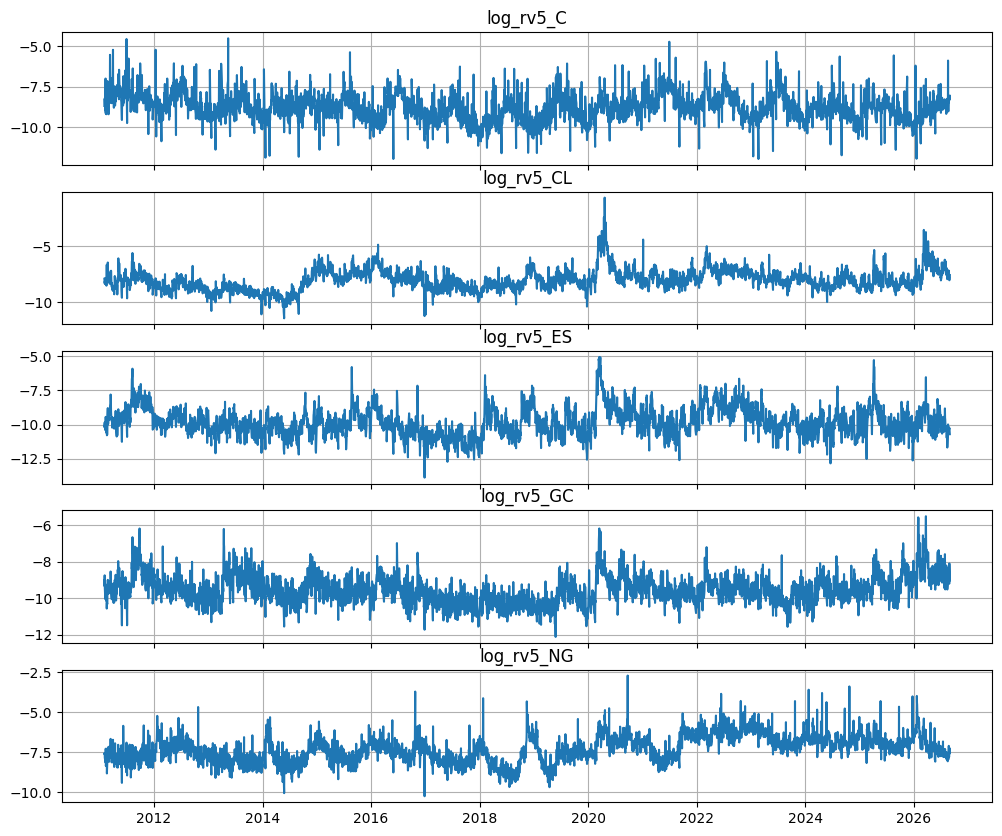

In [8]:
fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
columns_to_plot = [col for col in df.columns if "log_rv5_" in col]

for i, col in enumerate(columns_to_plot):
    axes[i].plot(df[col])
    axes[i].set_title(col)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [5]:
def fit_har_x(
    df_wide,
    target="ES",
    exog_symbols=None,
    metric="log_rv5",
    include_exog_horizons=False,
    include_leverage=False,  # Toggle for Corsi-Renò Leverage terms
    hac_lags=22,
):
  """Fits an OLS HAR, HAR-X, LHAR, or LHAR-X model with Newey-West standard errors.

  Parameters:
  -----------
  df_wide : pd.DataFrame
      Clean wide DataFrame aligned by date.
  target : str
      Target asset symbol (e.g. 'ES').
  exog_symbols : list of str, optional
      List of exogenous assets (e.g. ['CL'], ['CL', 'C'], or ['CL', 'C', 'GC',
      'NG']).
  metric : str
      Prefix for realized volatility metric (e.g. 'log_rv5' or 'rk_scaled').
  include_exog_horizons : bool
      If False: includes only daily lag-1 of exog.
      If True: includes daily, weekly, and monthly components for each exog
      asset.
  include_leverage : bool
      If True: includes daily, weekly, and monthly negative return shocks |min(r,
      0)|.
  hac_lags : int
      Newey-West truncation lag parameter.
  """
  if exog_symbols is None:
    exog_symbols = []

  # 1. Target: tomorrow's realized volatility (t+1)
  y_target = df_wide[f"{metric}_{target}"].shift(-1)

  # 2. Endogenous HAR components for target asset (at day t)
  X_dict = {
      f"{target}_d": df_wide[f"{metric}_{target}"],
      f"{target}_w": df_wide[f"{metric}_w_{target}"],
      f"{target}_m": df_wide[f"{metric}_m_{target}"],
  }

  # 3. Leverage components (Corsi & Renò)
  if include_leverage:
    ret = df_wide[f"ret_{target}"] # / 100.0  # Convert % returns to decimals
    ret_w = ret.rolling(5).mean()
    ret_m = ret.rolling(22).mean()

    X_dict[f"{target}_down_d"] = np.abs(np.minimum(ret, 0.0))
    X_dict[f"{target}_down_w"] = np.abs(np.minimum(ret_w, 0.0))
    X_dict[f"{target}_down_m"] = np.abs(np.minimum(ret_m, 0.0))

  # 4. Add Exogenous Regressors
  for sym in exog_symbols:
    if include_exog_horizons:
      X_dict[f"{sym}_d"] = df_wide[f"{metric}_{sym}"]
      X_dict[f"{sym}_w"] = df_wide[f"{metric}_w_{sym}"]
      X_dict[f"{sym}_m"] = df_wide[f"{metric}_m_{sym}"]
    else:
      X_dict[f"{sym}_d"] = df_wide[f"{metric}_{sym}"]

  # 5. Construct design matrix & align sample
  design_df = pd.DataFrame(X_dict)
  design_df["target_t1"] = y_target
  design_df = design_df.dropna()

  y = design_df["target_t1"]
  X = sm.add_constant(design_df.drop(columns=["target_t1"]))

  # 6. Fit OLS with HAC standard errors
  model = sm.OLS(y, X)
  results = model.fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})

  return results

In [6]:
# 1. Standard HAR Models (include_leverage=False)
model_es_solo = fit_har_x(df, target="ES", include_leverage=False)
model_har_oil = fit_har_x(
    df,
    target="ES",
    exog_symbols=["CL"],
    include_exog_horizons=True,
    include_leverage=False,
)
model_har_ng = fit_har_x(
    df,
    target="ES",
    exog_symbols=["NG"],
    include_exog_horizons=True,
    include_leverage=False,
)
model_har_energy = fit_har_x(
    df,
    target="ES",
    exog_symbols=["CL", "NG"],
    include_exog_horizons=True,
    include_leverage=False,
)
model_har_all3 = fit_har_x(
    df,
    target="ES",
    exog_symbols=["CL", "NG", "GC"],
    include_exog_horizons=True,
    include_leverage=False,
)

# 2. Leverage LHAR Models (include_leverage=True)
model_lhar_solo = fit_har_x(df, target="ES", include_leverage=True)
model_lhar_oil = fit_har_x(
    df,
    target="ES",
    exog_symbols=["CL"],
    include_exog_horizons=True,
    include_leverage=True,
)
model_lhar_ng = fit_har_x(
    df,
    target="ES",
    exog_symbols=["NG"],
    include_exog_horizons=True,
    include_leverage=True,
)
model_lhar_energy = fit_har_x(
    df,
    target="ES",
    exog_symbols=["CL", "NG"],
    include_exog_horizons=True,
    include_leverage=True,
)
model_lhar_all3 = fit_har_x(
    df,
    target="ES",
    exog_symbols=["CL", "NG", "GC"],
    include_exog_horizons=True,
    include_leverage=True,
)

# 3. Assemble all 10 models
models_all = {
    # Standard HAR Family
    "Baseline HAR": model_es_solo,
    "HAR-X (Oil)": model_har_oil,
    "HAR-X (NatGas)": model_har_ng,
    "HAR-X (Energy: Oil + NG)": model_har_energy,
    "HAR-X (Oil + NG + Gold)": model_har_all3,
    # Leverage LHAR Family
    "Baseline LHAR": model_lhar_solo,
    "LHAR-X (Oil)": model_lhar_oil,
    "LHAR-X (NatGas)": model_lhar_ng,
    "LHAR-X (Energy: Oil + NG)": model_lhar_energy,
    "LHAR-X (Oil + NG + Gold)": model_lhar_all3,
}

# 4. Build the comparison table matching your output format
summary_table_10 = pd.DataFrame(
    {
        "R²": [m.rsquared for m in models_all.values()],
        "Adj. R²": [m.rsquared_adj for m in models_all.values()],
        "AIC": [m.aic for m in models_all.values()],
        "BIC": [m.bic for m in models_all.values()],
        "F-Stat": [m.fvalue for m in models_all.values()],
        "Prob(F-Stat)": [m.f_pvalue for m in models_all.values()],
        "Log-Likelihood": [m.llf for m in models_all.values()],
    },
    index=models_all.keys(),
)

print(summary_table_10.round(4))

                               R²  Adj. R²        AIC        BIC     F-Stat  \
Baseline HAR               0.6948   0.6946  6869.2711  6894.4353  2140.2297   
HAR-X (Oil)                0.6951   0.6946  6872.3402  6916.3775  1160.6264   
HAR-X (NatGas)             0.6955   0.6950  6866.5933  6910.6306  1094.2022   
HAR-X (Energy: Oil + NG)   0.6958   0.6951  6869.1335  6932.0440   795.0095   
HAR-X (Oil + NG + Gold)    0.6971   0.6962  6857.9916  6939.7752   667.0350   
Baseline LHAR              0.7240   0.7236  6455.1194  6499.1198  1834.6132   
LHAR-X (Oil)               0.7243   0.7237  6456.6147  6519.4723  1237.6821   
LHAR-X (NatGas)            0.7253   0.7247  6442.5131  6505.3708  1246.0733   
LHAR-X (Energy: Oil + NG)  0.7256   0.7248  6444.5616  6526.2765   975.4460   
LHAR-X (Oil + NG + Gold)   0.7266   0.7256  6435.9018  6536.4741   778.3829   

                           Prob(F-Stat)  Log-Likelihood  
Baseline HAR                        0.0      -3430.6356  
HAR-X (Oil)   

In [7]:
# 1. Baseline LHAR for reference
model_lhar_baseline = fit_har_x(df, target="ES", include_leverage=True)

# 2. WITH CORN (All 4 Commodities: CL, C, GC, NG)
# (a) Full multi-horizon (Daily, Weekly, Monthly)
model_lhar_all_full = fit_har_x(
    df,
    target="ES",
    exog_symbols=["CL", "C", "GC", "NG"],
    include_exog_horizons=True,
    include_leverage=True,
)
# (b) Daily-only (No Weekly or Monthly commodity RV)
model_lhar_all_daily = fit_har_x(
    df,
    target="ES",
    exog_symbols=["CL", "C", "GC", "NG"],
    include_exog_horizons=False,
    include_leverage=True,
)

# 3. WITHOUT CORN (Energy & Gold: CL, NG, GC)
# (a) Full multi-horizon (Daily, Weekly, Monthly)
model_lhar_nocorn_full = fit_har_x(
    df,
    target="ES",
    exog_symbols=["CL", "NG", "GC"],
    include_exog_horizons=True,
    include_leverage=True,
)
# (b) Daily-only (No Weekly or Monthly commodity RV)
model_lhar_nocorn_daily = fit_har_x(
    df,
    target="ES",
    exog_symbols=["CL", "NG", "GC"],
    include_exog_horizons=False,
    include_leverage=True,
)

# 4. Compile comparison dictionary
lhar_matrix_models = {
    "Baseline LHAR (including Full d,w,m)": model_lhar_baseline,
    "LHAR-X (All 4 + Full d,w,m)": model_lhar_all_full,
    "LHAR-X (All 4 + Daily Only)": model_lhar_all_daily,
    "LHAR-X (No Corn + Full d,w,m)": model_lhar_nocorn_full,
    "LHAR-X (No Corn + Daily Only)": model_lhar_nocorn_daily,
}

# 5. Build summary table
summary_lhar_comparison = pd.DataFrame(
    {
        "Params (k)": [int(m.df_model + 1) for m in lhar_matrix_models.values()],
        "R²": [m.rsquared for m in lhar_matrix_models.values()],
        "Adj. R²": [m.rsquared_adj for m in lhar_matrix_models.values()],
        "AIC": [m.aic for m in lhar_matrix_models.values()],
        "BIC": [m.bic for m in lhar_matrix_models.values()],
        "F-Stat": [m.fvalue for m in lhar_matrix_models.values()],
        "Log-Likelihood": [m.llf for m in lhar_matrix_models.values()],
    },
    index=lhar_matrix_models.keys(),
)

print(summary_lhar_comparison.round(4))

                                      Params (k)      R²  Adj. R²        AIC  \
Baseline LHAR (including Full d,w,m)           7  0.7240   0.7236  6455.1194   
LHAR-X (All 4 + Full d,w,m)                   19  0.7267   0.7254  6440.7400   
LHAR-X (All 4 + Daily Only)                   11  0.7246   0.7239  6454.9370   
LHAR-X (No Corn + Full d,w,m)                 16  0.7266   0.7256  6435.9018   
LHAR-X (No Corn + Daily Only)                 10  0.7245   0.7239  6453.8776   

                                            BIC     F-Stat  Log-Likelihood  
Baseline LHAR (including Full d,w,m)  6499.1198  1834.6132      -3220.5597  
LHAR-X (All 4 + Full d,w,m)           6560.1695   661.6728      -3201.3700  
LHAR-X (All 4 + Daily Only)           6524.0805  1122.6726      -3216.4685  
LHAR-X (No Corn + Full d,w,m)         6536.4741   778.3829      -3201.9509  
LHAR-X (No Corn + Daily Only)         6516.7352  1247.2743      -3216.9388  


In [8]:
model_lhar_nocorn_full.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              target_t1   R-squared:                       0.727
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     778.4
Date:                Sun, 04 Oct 2026   Prob (F-statistic):               0.00
Time:                        13:57:04   Log-Likelihood:                -3202.0
No. Observations:                3967   AIC:                             6436.
Df Residuals:                    3951   BIC:                             6536.
Df Model:                          15                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.5572      0.169     -9.198      0.000      -1.889      -1.225
ES_d           0.4177      0.026     16.044      0.000       0.367       0.469
ES_w           0.2579      0.032      8.023      0.000       0.195       0.321
ES_m           0.1477      0.025      5.985      0.000       0.099       0.196
ES_down_d      0.1931      0.020      9.722      0.000       0.154       0.232
ES_down_w      0.3060      0.046      6.630      0.000       0.216       0.396
ES_down_m      0.2376      0.099      2.409      0.016       0.044       0.431
CL_d           0.0567      0.026      2.193      0.028       0.006       0.107
CL_w          -0.0816      0.037     -2.179      0.029      -0.155      -0.008
CL_m           0.0199      0.029      0.690      0.491      -0.037       0.077
NG_d          -0.0203      0.024     -0.862      0.389      -0.066       0.026
NG_w          -0.0621      0.039     -1.573      0.116      -0.139       0.015
NG_m           0.1215      0.034      3.578      0.000       0.055       0.188
GC_d          -0.0785      0.026     -3.018      0.003      -0.129      -0.028
GC_w           0.0217      0.038      0.577      0.564      -0.052       0.096
GC_m           0.0613      0.033      1.842      0.065      -0.004       0.126
==============================================================================
Omnibus:                      175.075   Durbin-Watson:                   2.075
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              427.655
Skew:                           0.244   Prob(JB):                     1.37e-93
Kurtosis:                       4.533   Cond. No.                         584.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 22 lags and without small sample correction
"""

In [9]:
def plot_har_residual_diagnostics(
    model_results, date_index=None, model_name="HAR-RV (ES)", lags=20, bins=70
):
    """Plots a 4-panel residual diagnostic grid for an OLS/HAR regression model."""
    # 1. Extract 1D residual series
    resid = model_results.resid

    # Attach proper date index if supplied (dropped last row due to t+1 forecast)
    if date_index is not None:
        resid = pd.Series(resid.values, index=date_index[: len(resid)])

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # --- Panel 1: Residuals Over Time ---
    axes[0, 0].plot(
        resid.index, resid.values, color="#1f77b4", lw=0.8, alpha=0.85
    )
    axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=0.9)
    axes[0, 0].set_title(
        f"Residuals Over Time: {model_name}", fontweight="bold"
    )
    axes[0, 0].set_ylabel("Residual")
    axes[0, 0].grid(True, alpha=0.3)

    # --- Panel 2: Density vs Theoretical Normal ---
    axes[0, 1].hist(
        resid, bins=bins, density=True, alpha=0.55, color="#2ca02c", edgecolor="none"
    )
    mu, std = stats.norm.fit(resid)
    xmin, xmax = axes[0, 1].get_xlim()
    x_pdf = np.linspace(xmin, xmax, 500)
    kurt = stats.kurtosis(resid, fisher=False)  # Pearson kurtosis (Normal = 3.0)
    skew = stats.skew(resid)

    axes[0, 1].plot(
        x_pdf,
        stats.norm.pdf(x_pdf, mu, std),
        "r--",
        lw=2,
        label=rf"Normal ($\mu={mu:.3f},\ \sigma={std:.3f}$)",
    )
    axes[0, 1].set_title(
        f"Empirical vs. Normal (Kurtosis: {kurt:.1f}, Skew: {skew:.2f})",
        fontweight="bold",
    )
    axes[0, 1].set_ylabel("Density")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # --- Panel 3: Q-Q Plot (Heavy Tails) ---
    sm.qqplot(resid, line="45", fit=True, ax=axes[1, 0], color="#1f77b4", alpha=0.5)
    axes[1, 0].set_title("Normal Q-Q Plot (Tail Extremity)", fontweight="bold")
    axes[1, 0].grid(True, alpha=0.3)

    # --- Panel 4: Autocorrelation Function (ACF) ---
    sm.graphics.tsa.plot_acf(resid, lags=lags, ax=axes[1, 1], alpha=0.05)
    axes[1, 1].set_title(
        f"Residual ACF (Up to {lags} Lags)", fontweight="bold"
    )
    axes[1, 1].set_xlabel("Lag")
    axes[1, 1].set_ylabel("Autocorrelation")
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

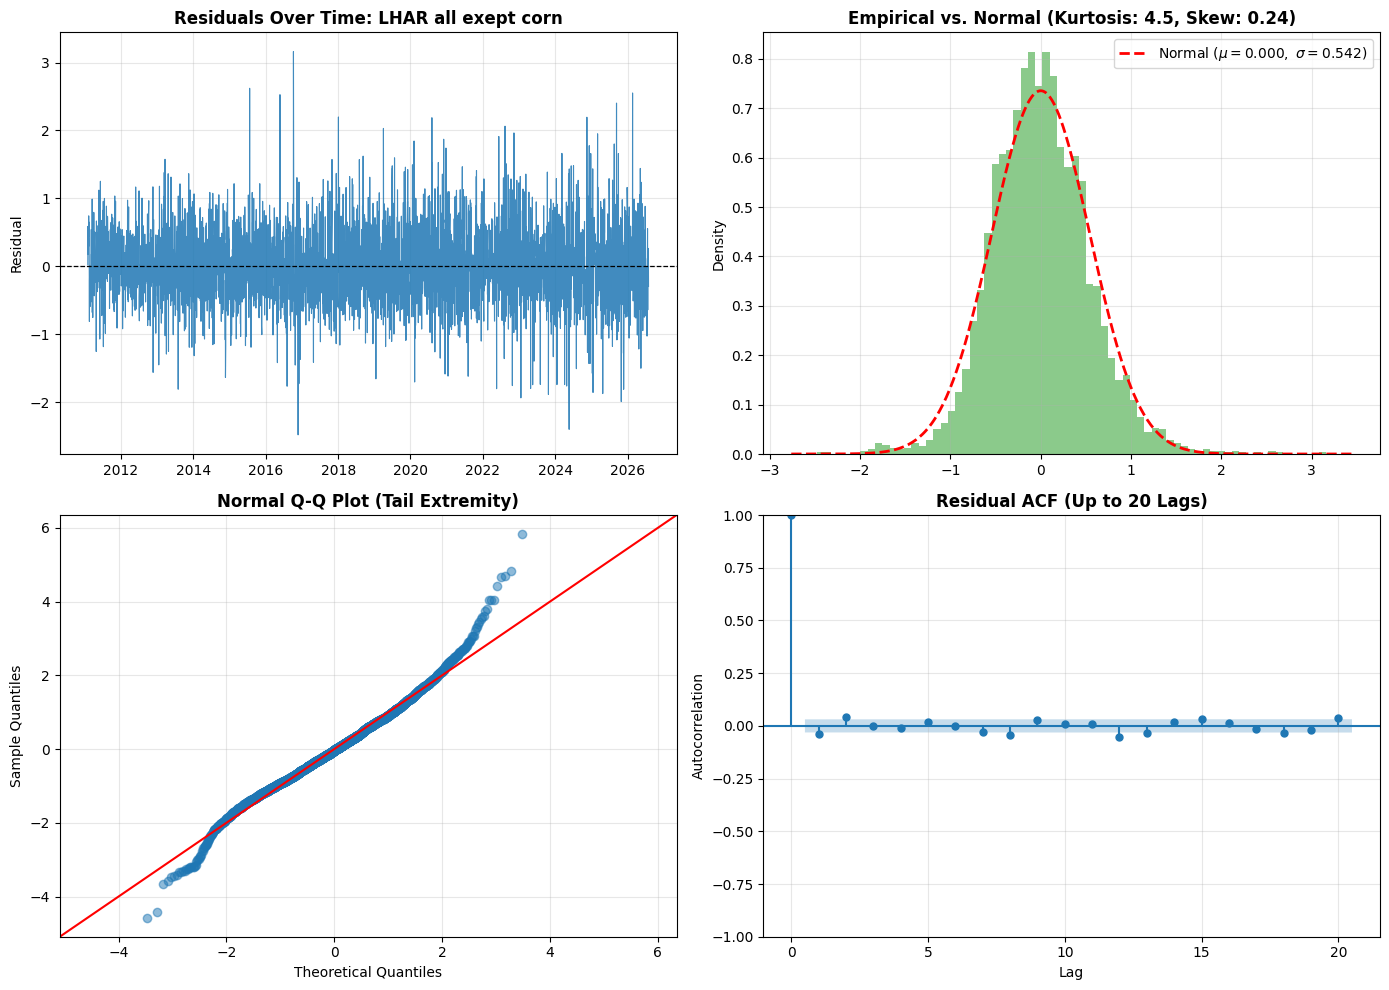

In [10]:
plot_har_residual_diagnostics(
    model_lhar_nocorn_full, date_index=df.index[:-1], model_name="LHAR all exept corn"
)